In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# IRIS CLASSIFICATION
Classify flowers into 0=setosa, 1=versicolor, 2=virginica

In [2]:
!pip install torch scikit-learn matplotlib seaborn

## DATA EXPLORATION

In [3]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data and target
X, y = load_iris(return_X_y = True)
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [4]:
# To see data
data = load_iris(as_frame = True)
df = data.frame
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [5]:
# Number of unique targets
print(df['target'].value_counts())

target
0    50
1    50
2    50
Name: count, dtype: int64


array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>],
       [<Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

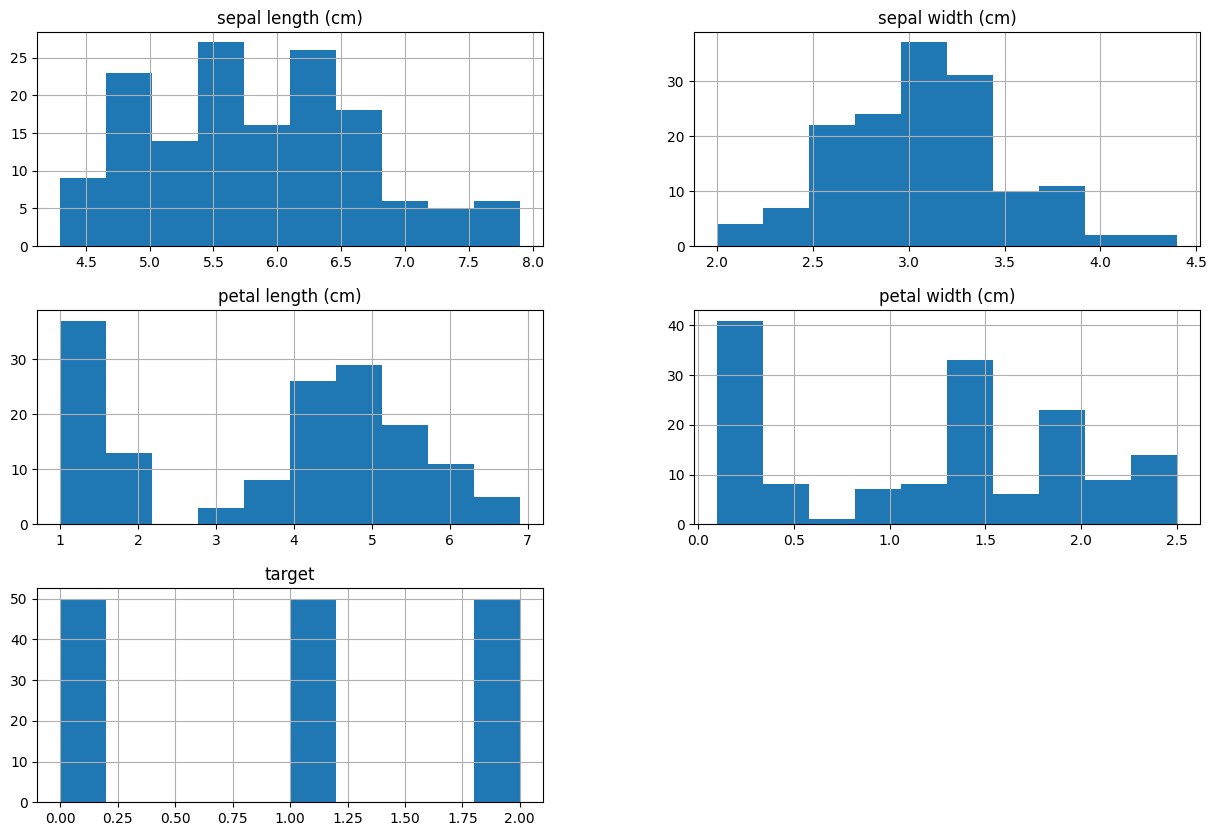

In [6]:
# Since numerical features- view distribution
df.hist(figsize = (15, 10))

In [7]:
# Check for missing vals
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


<Axes: >

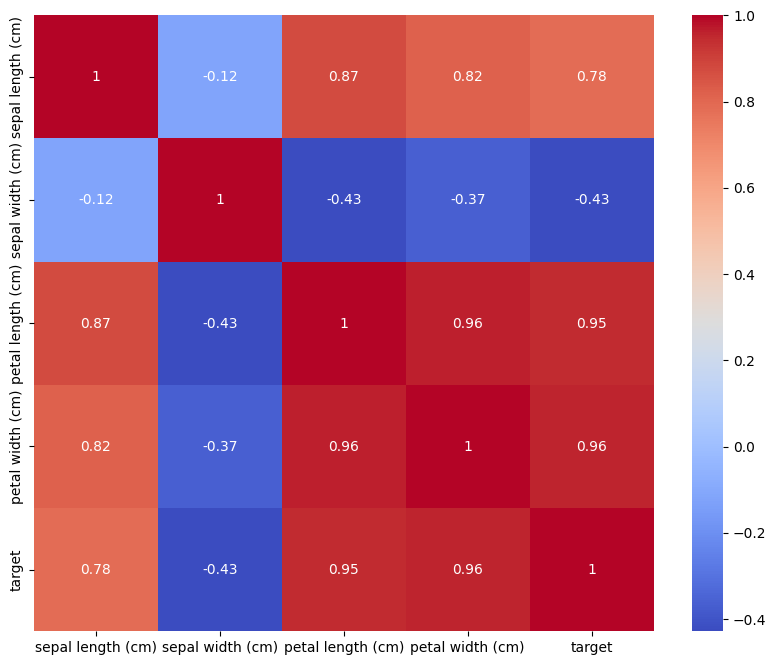

In [8]:
# Feature correlation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

## DATA PREPROCESSING

In [9]:
# Split data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# Scale X data because nns are scale sensitive
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# view train data labels
y_train

array([2, 1, 0, 2, 1, 0, 1, 1, 0, 2, 1, 1, 2, 0, 1, 1, 2, 2, 0, 0, 0, 0,
       2, 1, 2, 2, 2, 2, 1, 1, 1, 2, 0, 2, 2, 2, 0, 2, 1, 1, 1, 2, 2, 1,
       1, 0, 2, 1, 0, 1, 0, 2, 1, 2, 0, 1, 0, 2, 0, 0, 0, 1, 2, 0, 2, 0,
       0, 0, 1, 0, 2, 2, 2, 2, 1, 1, 2, 2, 0, 2, 1, 2, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 2, 2, 0, 0, 2, 1, 2, 0, 2, 2, 2, 1, 0, 1, 0, 2, 1, 0,
       2, 1, 1, 1, 2, 2, 1, 0, 2, 2])

In [11]:
# data to tensors -> tensor dataset -> load with data loader
X_train_scaled_tensor = torch.tensor(X_train_scaled, dtype = torch.float)
X_test_scaled_tensor = torch.tensor(X_test_scaled, dtype = torch.float)

y_train_tensor = torch.tensor(y_train, dtype = torch.long)
y_test_tensor = torch.tensor(y_test, dtype = torch.long)

In [12]:
# Create tensor dataset and data loader
train_dataset = TensorDataset(X_train_scaled_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)

In [13]:
# to find features for instances
X_train_scaled_tensor.shape

torch.Size([120, 4])

## MODEL ARCHITECTURE

In [14]:
# Define the neural net
class IrisNet(nn.Module):
    def __init__(self):
        super(IrisNet, self).__init__()
        self.fc1 = nn.Linear(4, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 3)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x # return raw logits

In [15]:
# Create model
model = IrisNet()

In [16]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [17]:
# Define the training loop
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in train_loader: # iterate over data loader to get batches
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch {epoch + 1}: Loss was {running_loss/len(train_loader)}')

Epoch 1: Loss was 1.1356911957263947
Epoch 2: Loss was 1.0805105865001678
Epoch 3: Loss was 1.0594011843204498
Epoch 4: Loss was 1.0129006057977676
Epoch 5: Loss was 0.9605954438447952
Epoch 6: Loss was 0.9361161142587662
Epoch 7: Loss was 0.9043691158294678
Epoch 8: Loss was 0.8671412169933319
Epoch 9: Loss was 0.788997158408165
Epoch 10: Loss was 0.7439161688089371
Epoch 11: Loss was 0.7053336501121521
Epoch 12: Loss was 0.6610907167196274
Epoch 13: Loss was 0.6493894010782242
Epoch 14: Loss was 0.6039623469114304
Epoch 15: Loss was 0.5576398521661758
Epoch 16: Loss was 0.5685594603419304
Epoch 17: Loss was 0.49702804535627365
Epoch 18: Loss was 0.47954413294792175
Epoch 19: Loss was 0.4606669247150421
Epoch 20: Loss was 0.45027906447649


## MODEL EVALUATION

In [18]:
# Evaluate model

model.eval()

with torch.no_grad(): # disable gradients for eval
    logits = model(X_test_scaled_tensor)
    probs = torch.softmax(logits, dim = 1)
    preds = torch.argmax(probs, dim = 1)

    correct = (preds == y_test_tensor).sum().item()
    accuracy = correct / len(y_test_tensor) * 100

print(f'Accuracy: {accuracy:.3f}')

Accuracy: 86.667
